In [1]:
#packages
import torch
from collections import Counter, defaultdict
import torch.nn as nn
import numpy as np
import math
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

In [2]:
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [3]:
import urllib.request
url = 'https://raw.githubusercontent.com/AChung1020/COMS_4995_AppliedML/main/Assignment_3/data.txt'
urllib.request.urlretrieve(url, 'data.txt')

('data.txt', <http.client.HTTPMessage at 0x7c8124d21fa0>)

## Data Prep

In [4]:
# load in data.txt (shakespeare stuff)
with open('data.txt', 'r') as f:
    corpus = f.read()

word_freq = Counter(corpus.split())
alphabet = sorted(set(corpus))

# initialize splits as list of characters
splits = {word: [c for c in word] for word in word_freq.keys()}

# build vocab until we have 500 tokens
vocab_size = 500
vocab = alphabet.copy()
merges = {}

while len(vocab) < vocab_size:
    # compute pair freqs

    pair_freqs = defaultdict(int)

    for word, freq in word_freq.items():
        split = splits[word]

        if len(split) == 1:
            continue

        for i in range(len(split) - 1):
            pair_freqs[(split[i], split[i + 1])] += freq

    if not pair_freqs:
        break

    # find best pair
    best_pair = max(pair_freqs, key=lambda p: pair_freqs[p])

    # merge best pair
    a, b = best_pair

    for word in word_freq:
        split = splits[word]

        if len(split) == 1:
            continue

        i = 0
        while i < len(split) - 1:

            if split[i] == a and split[i + 1] == b:
                split = split[:i] + [a + b] + split[i + 2:]
            else:
                i += 1
                
        splits[word] = split

    merges[best_pair] = a + b
    vocab.append(a + b)

In [5]:
def tokenize(text):
    words = text.split()
    
    tokens = []
    
    for idx, word in enumerate(words):
        if idx > 0:
            tokens.append(' ')
        
        word_tokens = [c for c in word if c in vocab_to_id]
        
        for pair, merge in merges.items():
            i = 0
            while i < len(word_tokens) - 1:
                if word_tokens[i] == pair[0] and word_tokens[i + 1] == pair[1]:
                    word_tokens = word_tokens[:i] + [merge] + word_tokens[i + 2:]
                else:
                    i += 1
        
        tokens.extend(word_tokens)
    
    return tokens

vocab_to_id = {token: idx for idx, token in enumerate(vocab)}
id_to_vocab = {idx: token for token, idx in vocab_to_id.items()}

tokens = tokenize(corpus)
token_ids = [vocab_to_id[token] for token in tokens]

print(f"total tokes: {len(token_ids)}")

total tokes: 641451


## sequence format

In [6]:
# create sequences with fixed length
seq_length = 128

# create input-target pairs
inputs = []
targets = []

for i in range(len(token_ids) - seq_length):
    input_seq = token_ids[i:i + seq_length]
    target_seq = token_ids[i + 1:i + seq_length + 1]
    inputs.append(input_seq)
    targets.append(target_seq)

# convert to tensors
inputs = torch.tensor(inputs, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# 80/20 train/validation split
split_idx = int(0.8 * len(inputs))

train_inputs = inputs[:split_idx]
train_targets = targets[:split_idx]

val_inputs = inputs[split_idx:]
val_targets = targets[split_idx:]

print(f"train set: {len(train_inputs)}")
print(f"val set: {len(val_inputs)}")

train set: 513058
val set: 128265


## Tiny Transformer Model

In [7]:
class RMSNorm(nn.Module):
    def __init__(self, dim_m, epsilon):
        super().__init__()

        self.epsilon = epsilon
        self.weight = nn.Parameter(torch.ones(dim_m))
    
    def forward(self, x):
        rms = torch.sqrt(self.epsilon + torch.mean(torch.pow(x, 2), dim=-1, keepdim=True))
        
        return (x / rms) * self.weight

class PositionalEncoding(nn.Module):
    def __init__(self, max_len, dim_m):
        super().__init__()

        self.dim_m = dim_m

        pos_enc = torch.zeros(max_len, self.dim_m)

        for p in range(max_len):
            for i in range(int(dim_m/2)):
                denominator = np.power(10000, 2*i/dim_m)

                pos_enc[p, 2 * i] = np.sin(p/denominator)
                pos_enc[p, 2 * i + 1] = np.cos(p/denominator)
        
        pos_enc = pos_enc.unsqueeze(0)
        self.register_buffer('pos_enc', pos_enc)
    
    def forward(self, x):
        return x + self.pos_enc[:, :x.size(1), :]

class CausalMHA(nn.Module):
    def __init__(self, dim_m, heads, dropout=0.1):
        super().__init__()

        self.dim_m = dim_m
        self.heads = heads
        self.head_dim = int(self.dim_m / self.heads)
        
        # full-dimension projections (standard approach)
        self.Q = nn.Linear(dim_m, dim_m, bias=False)
        self.K = nn.Linear(dim_m, dim_m, bias=False)
        self.V = nn.Linear(dim_m, dim_m, bias=False)

        #out layer to concatenate the heads
        self.out = nn.Linear(dim_m, dim_m)
        self.attn_dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False): 
        bs, seq_len, _ = x.shape

        # project full dimension, then reshape into heads
        q = self.Q(x).reshape(bs, seq_len, self.heads, self.head_dim).transpose(1, 2)
        k = self.K(x).reshape(bs, seq_len, self.heads, self.head_dim).transpose(1, 2)
        v = self.V(x).reshape(bs, seq_len, self.heads, self.head_dim).transpose(1, 2)

        #scaled dot product attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        
        # causal mask
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=q.device), diagonal=1).bool()
        scores = scores.masked_fill(causal_mask, float('-inf'))
        
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights_dropped = self.attn_dropout(attn_weights)
        
        # attention
        attn_output = torch.matmul(attn_weights_dropped, v)
        
        # combine heads
        attn_output = attn_output.transpose(1, 2).reshape(bs, seq_len, self.dim_m)
        
        output = self.out(attn_output)
        
        if return_attention:
            return output, attn_weights
        return output

class FFN(nn.Module):
    def __init__(self, dim_m, dim_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(dim_m, dim_ff)
        self.fc2 = nn.Linear(dim_ff, dim_m)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

In [8]:
class TransformerBlock(nn.Module): 
    def __init__(self, dim_m, heads, dim_ff, epsilon, dropout=0.1):
        super().__init__()
        self.attn = CausalMHA(dim_m, heads, dropout)
        self.ff = FFN(dim_m, dim_ff, dropout)
        self.norm1 = RMSNorm(dim_m, epsilon)
        self.norm2 = RMSNorm(dim_m, epsilon)

    def forward(self, x):
        x = x + self.attn(self.norm1(x)) 
        x = x + self.ff(self.norm2(x))
        return x

## Tiny Transformer

In [9]:
class TinyTransformer(nn.Module):
    def __init__(self, dim_m, heads, dim_ff, epsilon, vocab_size, max_len, n_layers, dropout=0.1):
        super().__init__()

        #embed tokens
        self.embedding = nn.Embedding(vocab_size, dim_m)

        # pos encoding
        self.pos_enc = PositionalEncoding(max_len, dim_m)
        self.embed_dropout = nn.Dropout(dropout)

        # transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(dim_m, heads, dim_ff, epsilon, dropout) for _ in range(n_layers)
        ])

        # norm at the end of the transformer blocks
        self.norm = RMSNorm(dim_m, epsilon)

        #output layer to predict next token
        self.out = nn.Linear(dim_m, vocab_size)
    
    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_enc(x)
        x = self.embed_dropout(x)
        
        # go through all the blocks
        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        x = self.out(x)

        return x

In [10]:
model = TinyTransformer(
    vocab_size= len(vocab),
    dim_m= 128,
    heads= 4,
    dim_ff= 512,
    max_len= seq_length,
    epsilon= 1e-6,
    n_layers= 3,
    dropout= 0.2
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [12]:
train_dataset = TensorDataset(train_inputs, train_targets)
val_dataset = TensorDataset(val_inputs, val_targets)

batch_size = 64

# for reproducibility of shuffling in DataLoader
g = torch.Generator()
g.manual_seed(seed)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

## Attnetion heatmaps

In [13]:
def plot_attention_heatmap(model, sample_input, actual_seq_len, id_to_vocab):
    model.eval()
    sample_input = sample_input.to(device)

    num_layers = len(model.blocks)
    num_heads = model.blocks[0].attn.heads

    with torch.no_grad():
        x = model.embedding(sample_input)
        x = model.pos_enc(x)

        all_attn_weights = []
        for block in model.blocks:
            x_norm = block.norm1(x)
            x_out, attn_weights = block.attn(x_norm, return_attention=True)
            all_attn_weights.append(attn_weights)
            x = x + x_out
            x = x + block.ff(block.norm2(x))

    token_ids = sample_input[0, :actual_seq_len].tolist()
    tokens_text = [id_to_vocab[idx] for idx in token_ids]
    tokens_display = [t if t.strip() != '' else '·' for t in tokens_text]

    global_min = min(
        all_attn_weights[l][0, h, :actual_seq_len, :actual_seq_len].min().item()
        for l in range(num_layers)
        for h in range(num_heads)
    )
    global_max = max(
        all_attn_weights[l][0, h, :actual_seq_len, :actual_seq_len].max().item()
        for l in range(num_layers)
        for h in range(num_heads)
    )

    fig, axes = plt.subplots(
        num_layers, num_heads,
        figsize=(5 * num_heads, 4 * num_layers),
        squeeze=False 
    )

    for layer_idx in range(num_layers):
        for head_idx in range(num_heads):
            ax = axes[layer_idx, head_idx]

            attn_head = all_attn_weights[layer_idx][0, head_idx, :actual_seq_len, :actual_seq_len].cpu().numpy()

            im = ax.imshow(attn_head, cmap='viridis', aspect='auto',
                           vmin=global_min, vmax=global_max)

            ax.set_title(f'Layer {layer_idx+1}, Head {head_idx+1}', fontsize=11, fontweight='bold')

            ax.set_xticks(range(actual_seq_len))
            ax.set_xticklabels(tokens_display, rotation=45, ha='right', fontsize=8)
            ax.set_yticks(range(actual_seq_len))
            ax.set_yticklabels(tokens_display, fontsize=8)

            if head_idx == 0:
                ax.set_ylabel('Query', fontsize=10)
            if layer_idx == num_layers - 1:
                ax.set_xlabel('Key', fontsize=10)

    plt.suptitle(f'Attention Weights', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    fig.colorbar(im, ax=axes.ravel().tolist(), label='Attention Weight', fraction=0.02, pad=0.04)
    plt.show()

## Train Loop

Epoch [1/5], Batch [500/8017], Loss: 3.7484
Epoch [1/5], Batch [1000/8017], Loss: 3.4628
Epoch [1/5], Batch [1500/8017], Loss: 3.3353
Epoch [1/5], Batch [2000/8017], Loss: 3.2662
Epoch [1/5], Batch [2500/8017], Loss: 3.2013
Epoch [1/5], Batch [3000/8017], Loss: 3.0940
Epoch [1/5], Batch [3500/8017], Loss: 3.0842
Epoch [1/5], Batch [4000/8017], Loss: 3.0611
Epoch [1/5], Batch [4500/8017], Loss: 2.9714
Epoch [1/5], Batch [5000/8017], Loss: 2.9952
Epoch [1/5], Batch [5500/8017], Loss: 2.9016
Epoch [1/5], Batch [6000/8017], Loss: 2.9181
Epoch [1/5], Batch [6500/8017], Loss: 2.8735
Epoch [1/5], Batch [7000/8017], Loss: 2.8299
Epoch [1/5], Batch [7500/8017], Loss: 2.7802
Epoch [1/5], Batch [8000/8017], Loss: 2.7646
Epoch [1/5] - Train Loss: 3.1329, Val Loss: 2.9959
------------------------------------------------------------


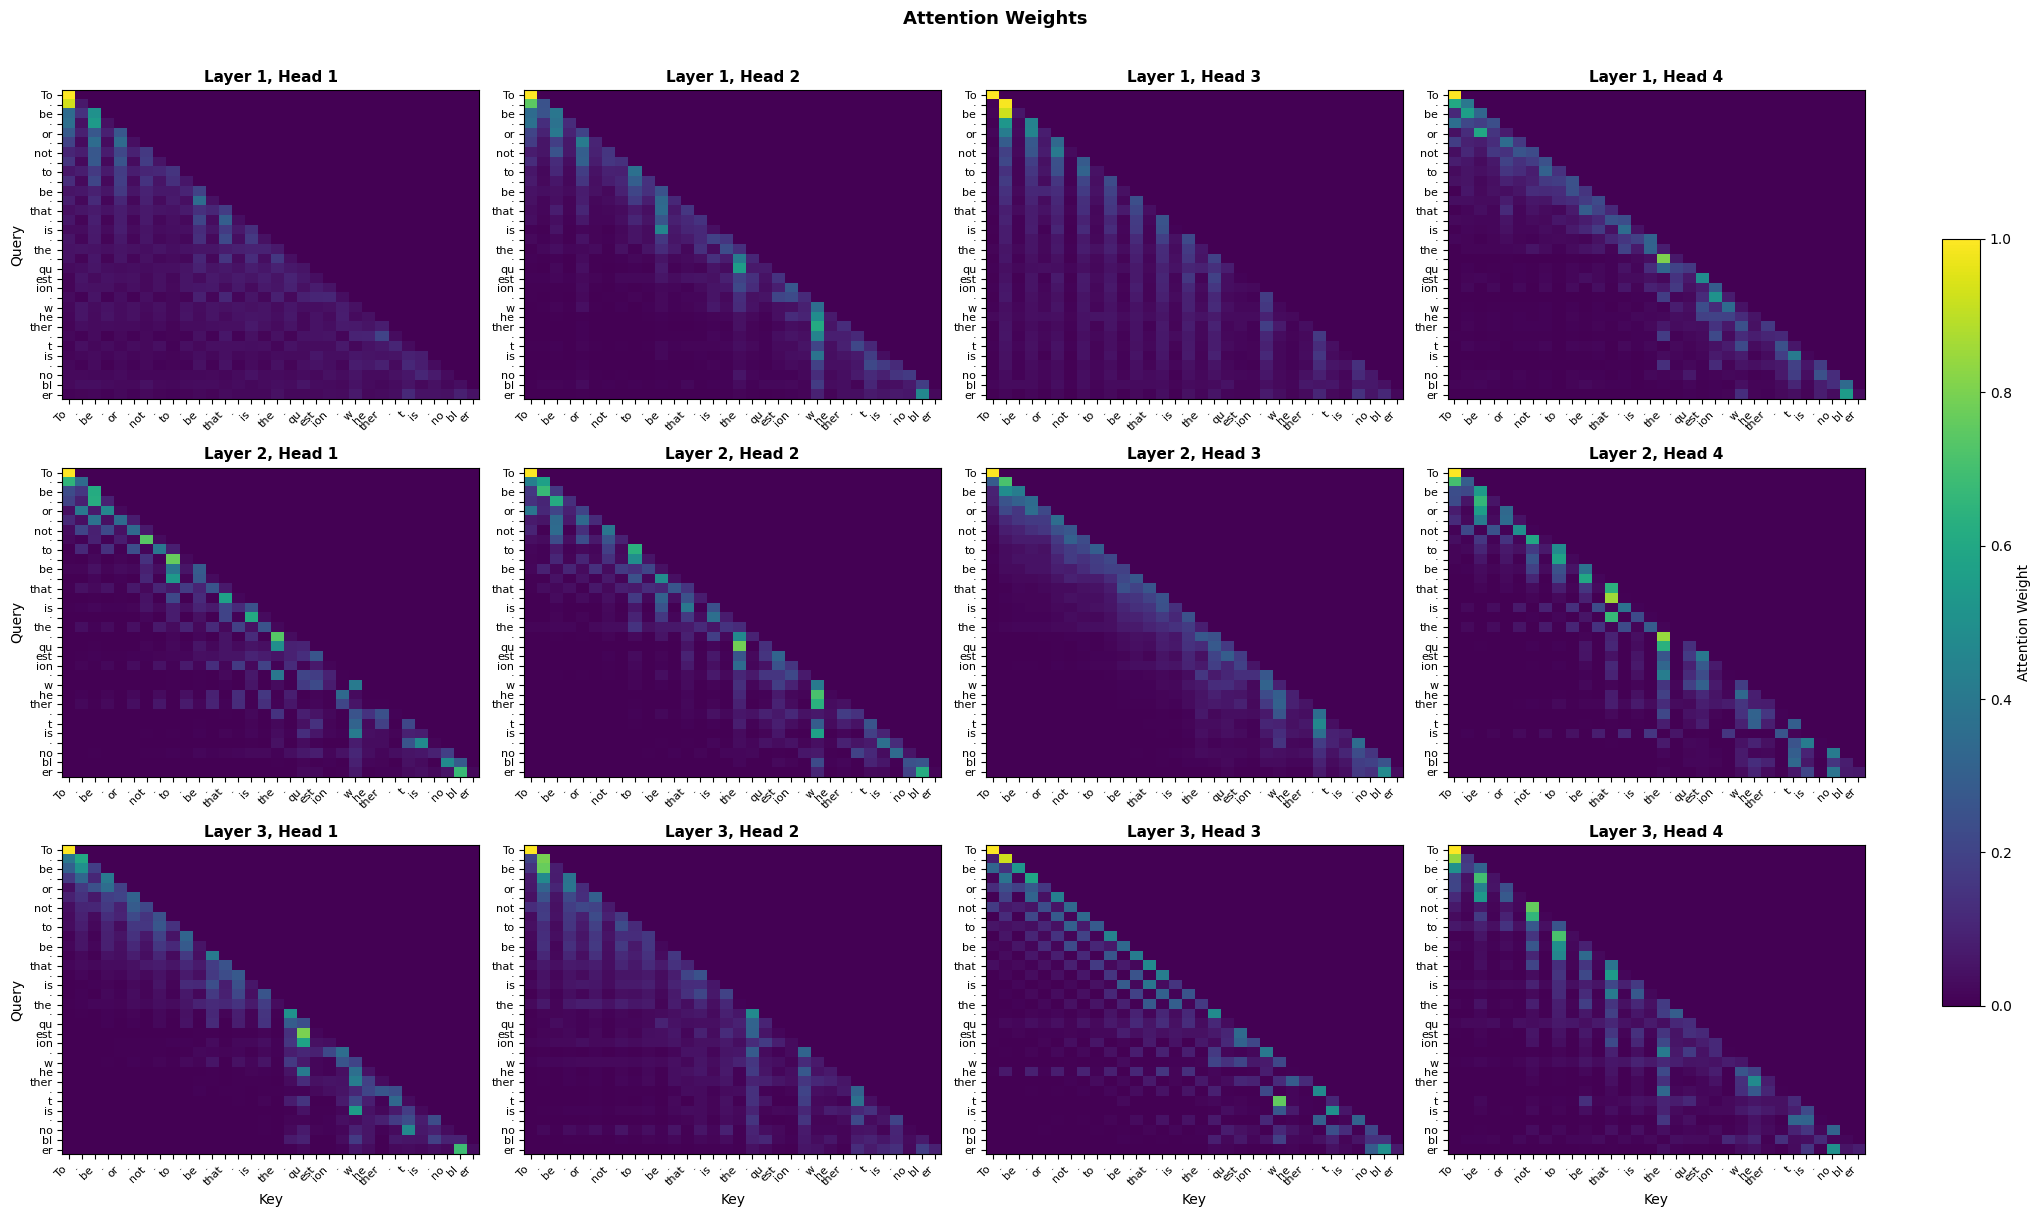

<Figure size 640x480 with 0 Axes>

Epoch [2/5], Batch [500/8017], Loss: 2.7896
Epoch [2/5], Batch [1000/8017], Loss: 2.6947
Epoch [2/5], Batch [1500/8017], Loss: 2.6942
Epoch [2/5], Batch [2000/8017], Loss: 2.7392
Epoch [2/5], Batch [2500/8017], Loss: 2.6331
Epoch [2/5], Batch [3000/8017], Loss: 2.6639
Epoch [2/5], Batch [3500/8017], Loss: 2.6545
Epoch [2/5], Batch [4000/8017], Loss: 2.6259
Epoch [2/5], Batch [4500/8017], Loss: 2.5779
Epoch [2/5], Batch [5000/8017], Loss: 2.6191
Epoch [2/5], Batch [5500/8017], Loss: 2.5514
Epoch [2/5], Batch [6000/8017], Loss: 2.5771
Epoch [2/5], Batch [6500/8017], Loss: 2.5088
Epoch [2/5], Batch [7000/8017], Loss: 2.4908
Epoch [2/5], Batch [7500/8017], Loss: 2.5238
Epoch [2/5], Batch [8000/8017], Loss: 2.4879
Epoch [2/5] - Train Loss: 2.6207, Val Loss: 2.8426
------------------------------------------------------------
Epoch [3/5], Batch [500/8017], Loss: 2.4900
Epoch [3/5], Batch [1000/8017], Loss: 2.4808
Epoch [3/5], Batch [1500/8017], Loss: 2.4213
Epoch [3/5], Batch [2000/8017], Los

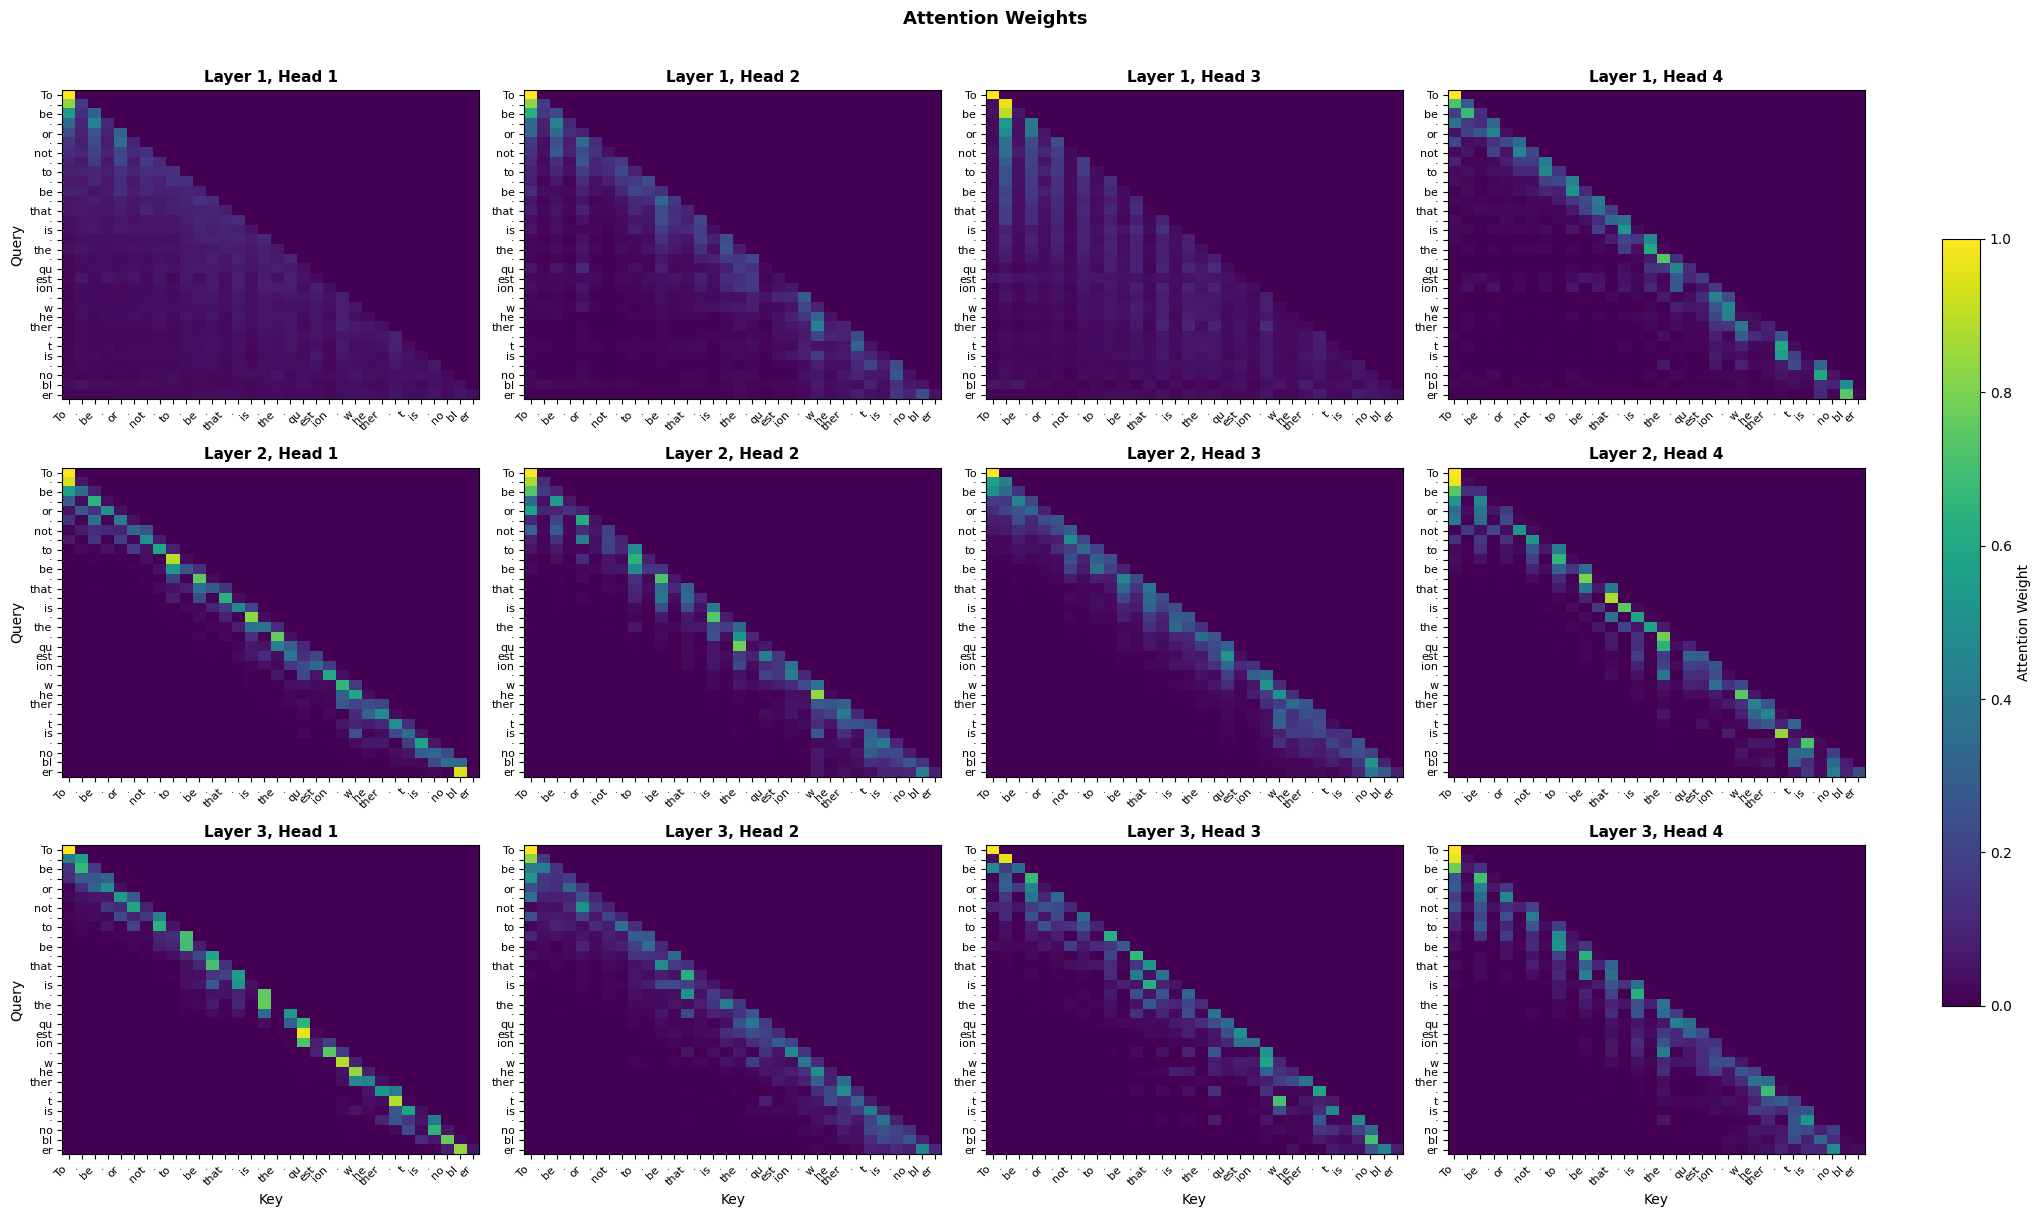

<Figure size 640x480 with 0 Axes>

Epoch [4/5], Batch [500/8017], Loss: 2.3709
Epoch [4/5], Batch [1000/8017], Loss: 2.3516
Epoch [4/5], Batch [1500/8017], Loss: 2.3636
Epoch [4/5], Batch [2000/8017], Loss: 2.3885
Epoch [4/5], Batch [2500/8017], Loss: 2.4150
Epoch [4/5], Batch [3000/8017], Loss: 2.4196
Epoch [4/5], Batch [3500/8017], Loss: 2.3753
Epoch [4/5], Batch [4000/8017], Loss: 2.4028
Epoch [4/5], Batch [4500/8017], Loss: 2.3814
Epoch [4/5], Batch [5000/8017], Loss: 2.3095
Epoch [4/5], Batch [5500/8017], Loss: 2.4036
Epoch [4/5], Batch [6000/8017], Loss: 2.3341
Epoch [4/5], Batch [6500/8017], Loss: 2.3442
Epoch [4/5], Batch [7000/8017], Loss: 2.3176
Epoch [4/5], Batch [7500/8017], Loss: 2.3263
Epoch [4/5], Batch [8000/8017], Loss: 2.3264
Epoch [4/5] - Train Loss: 2.3684, Val Loss: 2.7803
------------------------------------------------------------
Epoch [5/5], Batch [500/8017], Loss: 2.4158
Epoch [5/5], Batch [1000/8017], Loss: 2.3082
Epoch [5/5], Batch [1500/8017], Loss: 2.2961
Epoch [5/5], Batch [2000/8017], Los

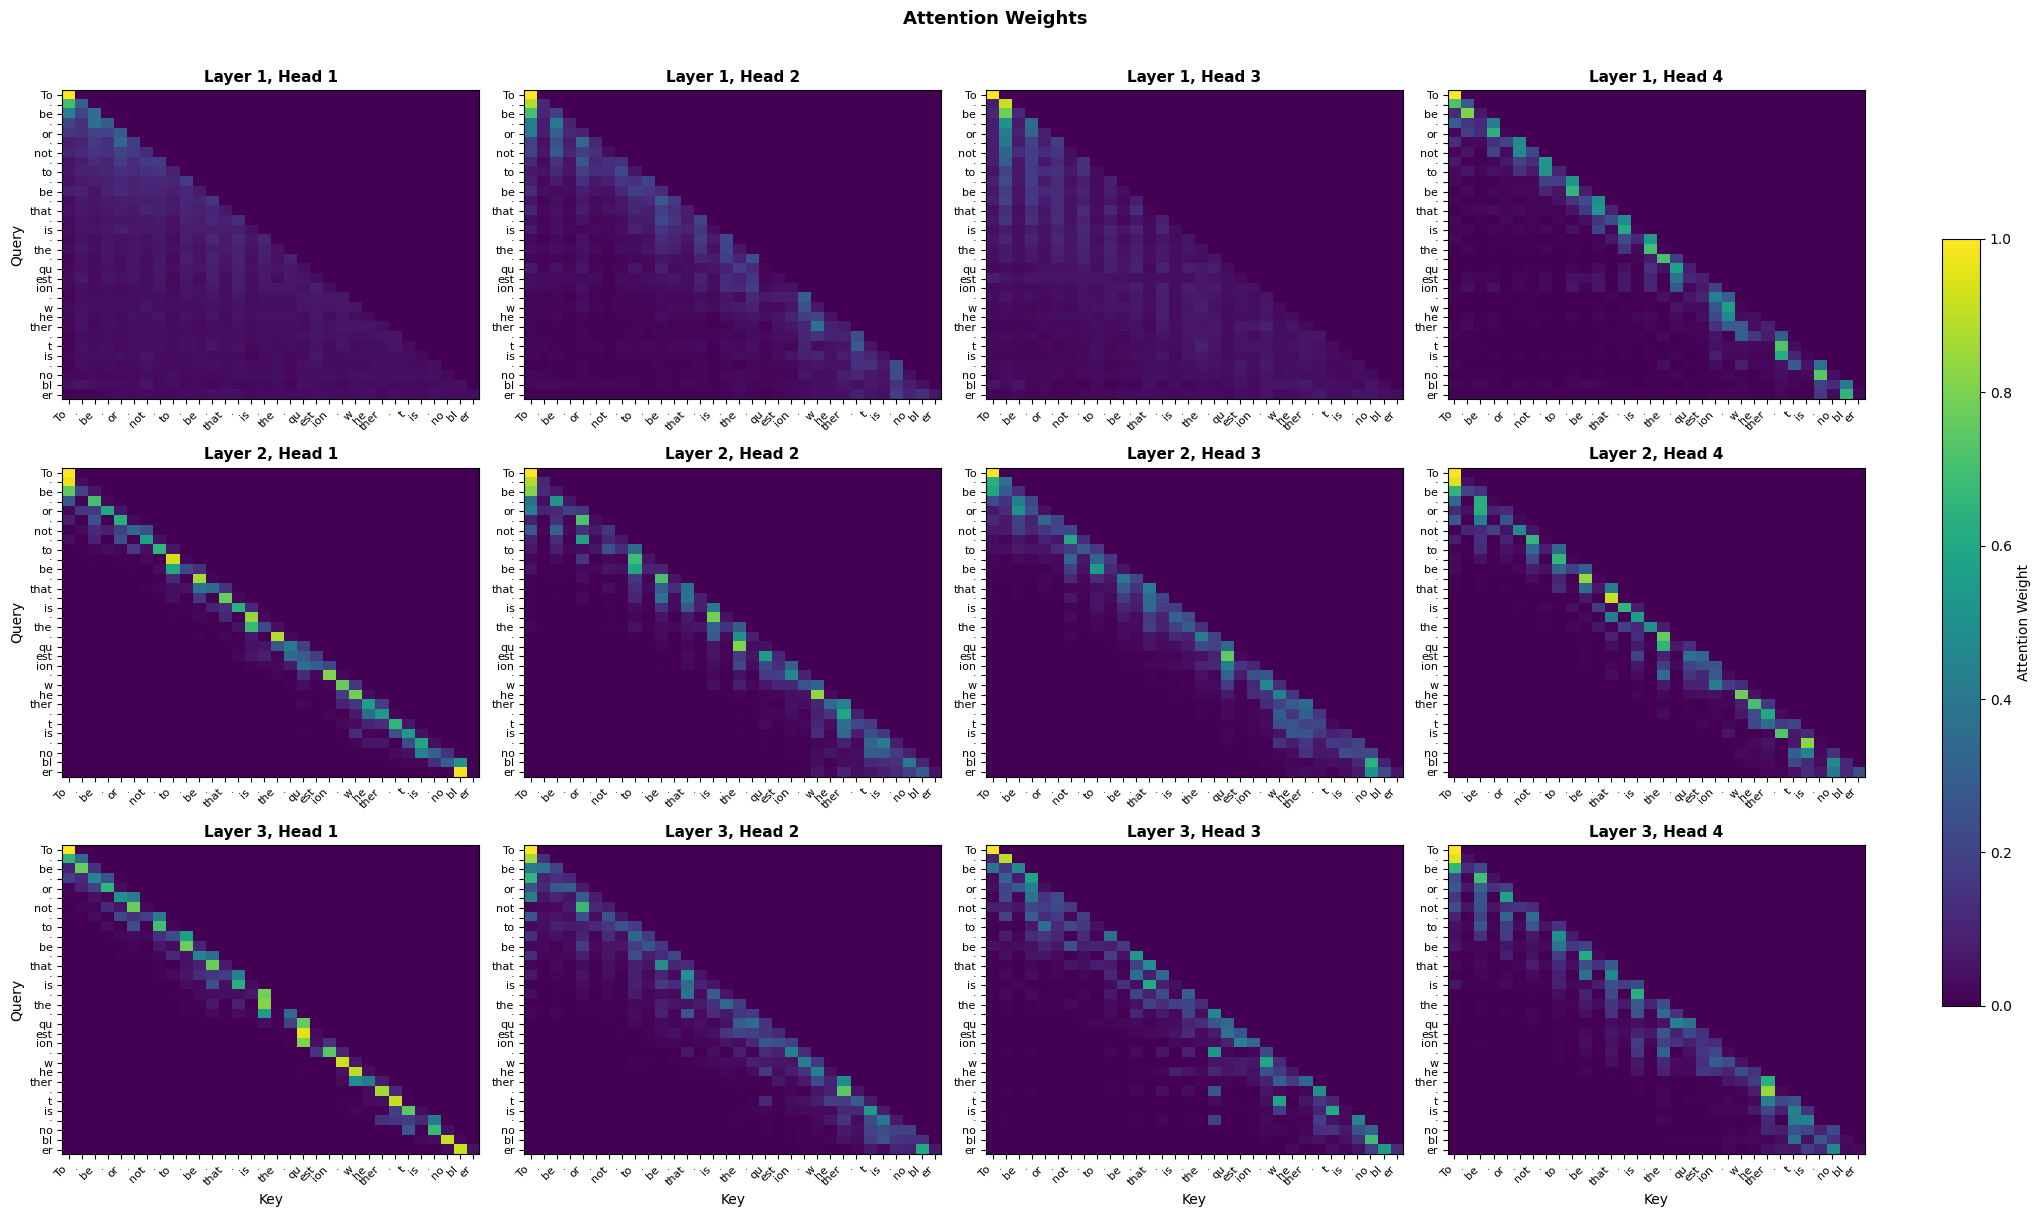

<Figure size 640x480 with 0 Axes>

In [14]:
num_epochs = 5
train_losses = []
val_losses = []

# prepare sample input for attention visualization
prompt = "To be or not to be that is the question whether tis nobler"
prompt_tokens = tokenize(prompt)
actual_seq_len = min(len(prompt_tokens), seq_length)
prompt_token_ids = [vocab_to_id[token] for token in prompt_tokens[:actual_seq_len]]

pad_id = vocab_to_id[' ']
if len(prompt_token_ids) < seq_length:
    prompt_token_ids = prompt_token_ids + [pad_id] * (seq_length - len(prompt_token_ids))

sample_input = torch.tensor([prompt_token_ids], dtype=torch.long)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch_idx, (inputs_batch, targets_batch) in enumerate(train_loader):
        inputs_batch = inputs_batch.to(device)
        targets_batch = targets_batch.to(device)
        
        logits = model(inputs_batch)
        
        loss = criterion(logits.view(-1, len(vocab)), targets_batch.view(-1))
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
        if (batch_idx + 1) % 500 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    train_loss = train_loss / len(train_loader)
    model.eval()

    val_loss = 0

    with torch.no_grad():
        for inputs_batch, targets_batch in val_loader:
            inputs_batch = inputs_batch.to(device)
            targets_batch = targets_batch.to(device)
            
            logits = model(inputs_batch)
            loss = criterion(logits.view(-1, len(vocab)), targets_batch.view(-1))
            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    train_losses.append(train_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    print("-" * 60)

    # save attention heatmaps at epochs 1, 3, and 5
    if epoch + 1 in [1, 3, 5]:
        plot_attention_heatmap(model, sample_input, actual_seq_len, id_to_vocab)
        plt.savefig(f'attention_epoch_{epoch+1}.png', bbox_inches='tight', dpi=150)
        plt.show()
        model.train()

## Visualization & Interpretation

In [15]:
model.eval()
total_loss = 0
total_tokens = 0

with torch.no_grad():
    for inputs_batch, targets_batch in val_loader:
        inputs_batch = inputs_batch.to(device)
        targets_batch = targets_batch.to(device)
        
        logits = model(inputs_batch)
        
        loss = criterion(logits.view(-1, len(vocab)), targets_batch.view(-1))
        
        total_loss += loss.item() * inputs_batch.size(0) * inputs_batch.size(1)
        total_tokens += inputs_batch.size(0) * inputs_batch.size(1)

avg_loss = total_loss / total_tokens
perplexity = math.exp(avg_loss)

print(f"Val Loss: {avg_loss:.4f}")
print(f"Perplexity: {perplexity:.2f}")

Val Loss: 2.7661
Perplexity: 15.90


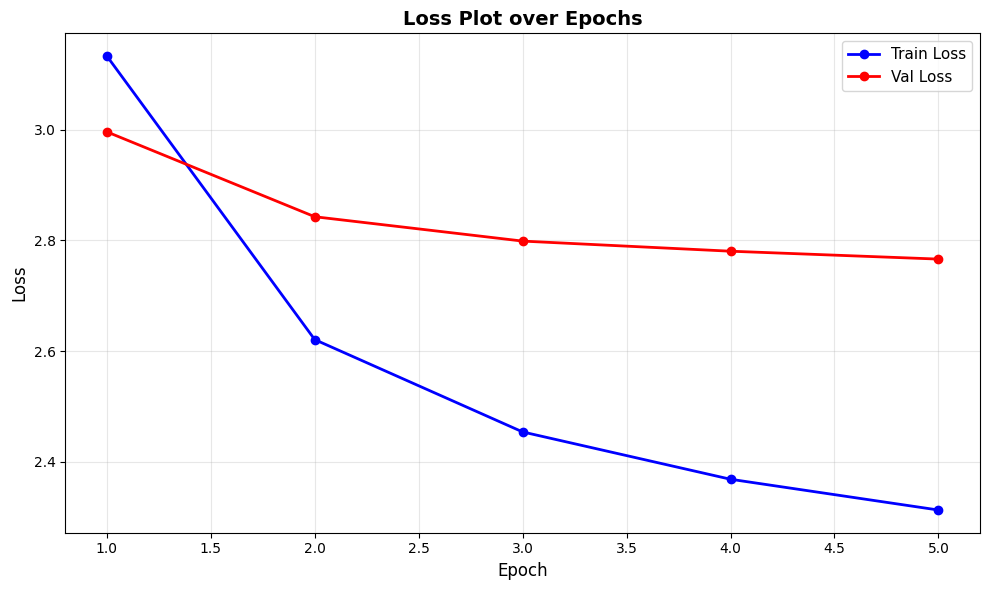

In [17]:
plt.figure(figsize=(10, 6))
epochs = range(1, len(train_losses) + 1)
plt.plot(epochs, train_losses, 'b-o', label='Train Loss', linewidth=2)
plt.plot(epochs, val_losses, 'r-o', label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss Plot over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
def generate(model, prompt, max_new_tokens=100, temperature=0.8):
    model.eval()
    
    tokens = tokenize(prompt)
    token_ids = [vocab_to_id[t] for t in tokens]
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            # truncate to context length if needed
            input_ids = token_ids[-seq_length:]
            input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
            
            logits = model(input_tensor)
            
            # get logits for the last token
            next_logits = logits[0, -1, :] / temperature
            probs = F.softmax(next_logits, dim=-1)
            
            next_token = torch.multinomial(probs, num_samples=1).item()
            token_ids.append(next_token)
    
    generated_text = ''.join([id_to_vocab[i] for i in token_ids])
    return generated_text

# generate samples
prompts = [
    "To be or not to be",
    "O Romeo Romeo",
    "Now is the winter of"
]

for prompt in prompts:
    for temp in [0.5, 0.8, 1.0]:
        print(f"Prompt: '{prompt}'")
        print(f"Generated: {generate(model, prompt, temperature=temp)}")
        print("-" * 60)

Prompt: 'To be or not to be'
Generated: To be or not to be not but I am dead. HASTINGS: So that I have been my lord, though never I have spoke to my son it in the people. First Senator: I pray you, sir; Marry, I have said to hear
------------------------------------------------------------
Prompt: 'To be or not to be'
Generated: To be or not to be return, Once all the crown, And foul in the mind of our punishment, If live wanders and for their souls, Your ballading to the body and virtue, And tell him grief, and in 
------------------------------------------------------------
Prompt: 'To be or not to be'
Generated: To be or not to be under to show for Catesby; but indeed lues to him. CATESBY: Will you that here? PERDITA: How must see the world of day? Let's dear body. CAMILLLO: Sir, Herm
------------------------------------------------------------
Prompt: 'O Romeo Romeo'
Generated: O Romeo Romeo banish'd me and honour, Clifford, and no more than I do be a scarce and first, Which is a p